# Small-Scale Experiments

### Imports


In [1]:
import cupy
import matplotlib.pyplot as plt
import numpy as np
import s3fs
import zarr

from deep_neurographs.utils import swc_util, util
from scipy.spatial import KDTree
from scipy.spatial.distance import euclidean as dist
from scipy.ndimage import gaussian_laplace

from time import time
from tifffile import imwrite

from aind_exaspim_soma_detection import soma_proposal_generation as spg
from aind_exaspim_soma_detection.utils import img_util

%matplotlib inline

IMG_PREFIX = {
    "685221": "exaSPIM_685221_2024-04-12_11-46-38_fusion_2024-07-22_21-00-15",
    "703070": "exaSPIM_703070_2024-07-09_12-52-33_flatfield-correction_2024-07-18_12-43-27_fusion_2024-08-02_17-11-59",
    "706301": "exaSPIM_706301_2024-04-23_11-24-24_fusion_2024-05-21_00-00-03",
    "708369": "exaSPIM_708369_2024-04-08_15-20-36_fusion_2024-05-20_23-30-43",
    "709393": "exaSPIM_709393_2024-04-17_09-37-51_fusion_2024-07-27_00-20-20",
    "715345": "exaSPIM_715345_2024-06-07_10-03-37_fusion_2024-07-02_10-30-40"
}

In [2]:
# Subroutines
def get_img_patch(img, voxel, shape, from_center=True):
    start, end = img_util.get_start_end(voxel, shape, from_center=from_center)
    return img[0, 0, start[2]:end[2], start[1]:end[1], start[0]:end[0]]


def merge_radius(intensity):
    """
    Evaluates linear function fit to the points (100, 0) and (10,000, 100).

    """
    return min((1 / 99) * intensity - (100 / 99), 150)


def find_candidates(img, offset, window_size):
    # Read patch
    img_patch = get_img_patch(img, offset, window_size, from_center=False)
    if np.max(img_patch) < 100:
        return list()

    # Detect candidates
    blobs = spg.detect_blobs(img_patch)
    centers = spg.get_centroids(img_patch, blobs)
    ## to xyz = local_voxel_to_physical(voxel[::-1], offset)
    return filter_centers(img_patch, centers, offset)


# Filter points
def filter_centers_by_brightness(img_patch, centers):
    brightness = [img_patch[c] for c in centers]
    kdtree = KDTree(centers)  # convert to physical coords
    filtered_centers = list()
    visited = set()
    for idx in np.argsort(brightness)[::-1]:
        if centers[idx] not in visited:
            # Keep center
            filtered_centers.append(centers[idx])

            # Filter bright centers relatively close
            radius = merge_radius(brightness[idx])
            idxs = kdtree.query_ball_point(centers[idx], radius)
            for voxel in kdtree.data[idxs]:
                voxel = tuple([int(v) for v in voxel])
                if img_patch[voxel] > min(brightness[idx], 5000) * 0.5:
                    visited.add(voxel)

            # Filter nearby centers
            idxs = kdtree.query_ball_point(centers[idx], 6)
            for voxel in kdtree.data[idxs]:
                voxel = tuple([int(v) for v in voxel])
                visited.add(voxel)
    return filtered_centers


### Opem img

In [3]:
# Parameters
s3_bucket = "aind-open-data"
dataset = "706301"
downsample_factor = 4

# Initializations
fs = s3fs.S3FileSystem()
s3_url = f"s3://{s3_bucket}/{IMG_PREFIX[dataset]}/fused.zarr/{downsample_factor}/"

# Open img
store = s3fs.S3Map(root=s3_url, s3=fs)
img = zarr.open(store, mode='r')
print("img.shape:", img.shape)

img.shape: (1, 1, 1812, 1821, 3895)


### Read img

In [4]:
traceable_somas = [
    [18403.324, 11245.411, 2675.9985],
    [23425.596, 8926.942, 2185.401],
    [18400.334,11231.872,2683.3584],
    [21624.133,7740.173,12768.359],
    [22883.316,4323.8574,16284.648],
    [43937.27,5479.154,12344.152],
]

bright_nonsomas = [
    [20026.29,6470.747,14384.427],
    [18330.354,3822.579,14477.964],
    [22800.148,2251.1611,16850.379],
    [37846.895,6913.5713,20431.992],
    [43469.51,4820.5303,16769.32],
    [44225.082,4402.9487,15589.198],
    [22086.203,16967.01,14625.586],
    [20239.145,21295.611,11517.228],
]

# Objects Detected: 588


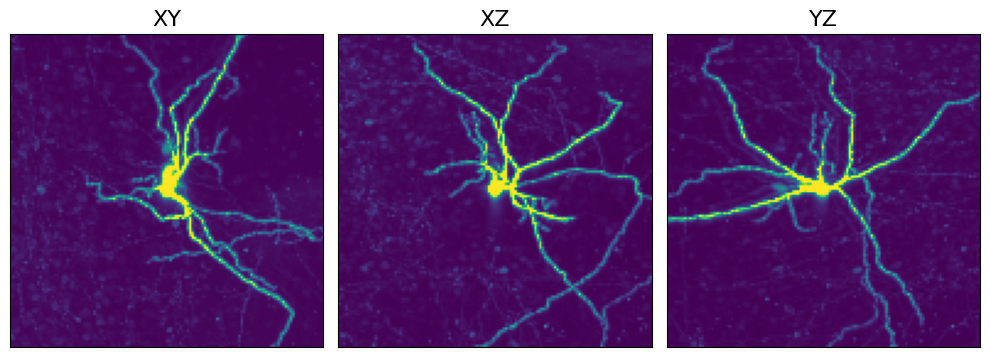

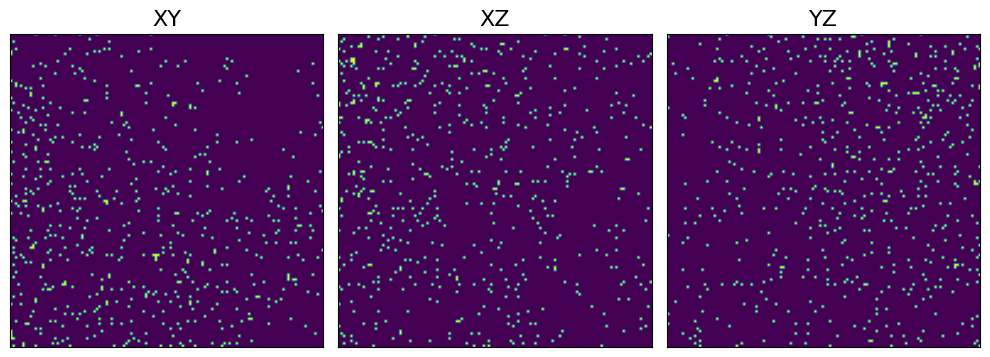

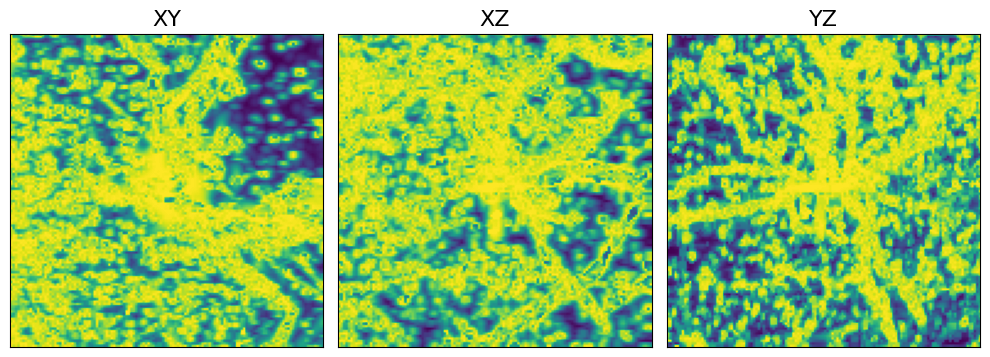

In [5]:
# Region of interest
idx = 4
shape = [128, 128, 128]
from_center = True

# Read img
voxel = img_util.to_voxels([22883.316,4323.8574,16284.648], downsample_factor=downsample_factor)
img_patch = get_img_patch(img, voxel, shape, from_center=from_center)
value = np.max(img_patch)

# Find blob centroids
blobs = spg.detect_blobs(img_patch)
centers = spg.get_centroids(img_patch, blobs)

# Heuristic-based Filtering
centers = filter_centers_by_brightness(img_patch, centers)
# --> add gausian fitting

# Visualize
spots_img = np.zeros(img_patch.shape)
for center in centers:
    spots_img = img_util.mark_voxel(spots_img, center)

# Plot mips
print("# Objects Detected:", len(centers))
img_util.plot_mips(img_patch, clip_bool=True)
img_util.plot_mips(spots_img)
img_util.plot_mips(gaussian_laplace(img_patch, 2))


In [6]:
imwrite("img_patch.tiff", img_patch)
imwrite("candidates.tiff", spots_img)

In [7]:
stop

NameError: name 'stop' is not defined

## Large-Scale Experiment

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

import os
import random


def sliding_window_coords_3d(img, window_size, overlap):
    # Calculate the stride based on the overlap and window size
    stride = tuple(w - o for w, o in zip(window_size, overlap))

    # Get dimensions of the  and window
    _, _, z_dim, y_dim, x_dim = img.shape
    z_win, y_win, x_win = window_size
    z_stride, y_stride, x_stride = stride

    # Loop over the  with the sliding window
    coords = []
    for x in range(0, x_dim - x_win + 1, x_stride):
        for y in range(0, y_dim - y_win + 1, y_stride):
            for z in range(0, z_dim - z_win + 1, z_stride):
                coords.append((x, y, z))
    return coords


def local_voxel_to_physical(local_voxel, offset):
    global_voxel = np.array([v + o for v, o in zip(local_voxel, offset)])
    return img_util.to_world(global_voxel * 2 ** downsample_factor)


### Soma Candidate Detection

In [ ]:
# Parameters
window_size = (128, 128, 128)
overlap = (32, 32, 32)

# Initializations
coords = sliding_window_coords_3d(img, window_size, overlap)
output_dir = "/root/capsule/results/soma_candidates"
util.mkdir(output_dir, delete=True)
print("# img patches:", len(coords))

# Detection
with ThreadPoolExecutor() as executor:
    # Assign threads
    threads = list()
    for coord in coords:  #random.sample(coords, 1000):
        threads.append(
            executor.submit(find_candidates, img, coord, window_size)
        )

    # Process results
    centers = list()
    pbar = tqdm(total=len(threads))
    for thread in as_completed(threads):
        centers.extend(thread.result())
        pbar.update(1)

print("# Candidates Detected:", len(centers))

# Save somas
with ThreadPoolExecutor() as executor:
    threads = list()
    for i, xyz in enumerate(candidates):
        path = os.path.join(output_dir, f"{i + 1}.swc")
        threads.append(
            executor.submit(
                swc_util.save_point, path, xyz, 30, color="1.0 0.0 0.0"
            )
        )

    pbar = tqdm(total=len(threads))
    for _ in as_completed(threads):
        pbar.update(1)


Fit accepted: 0.9082373594378474


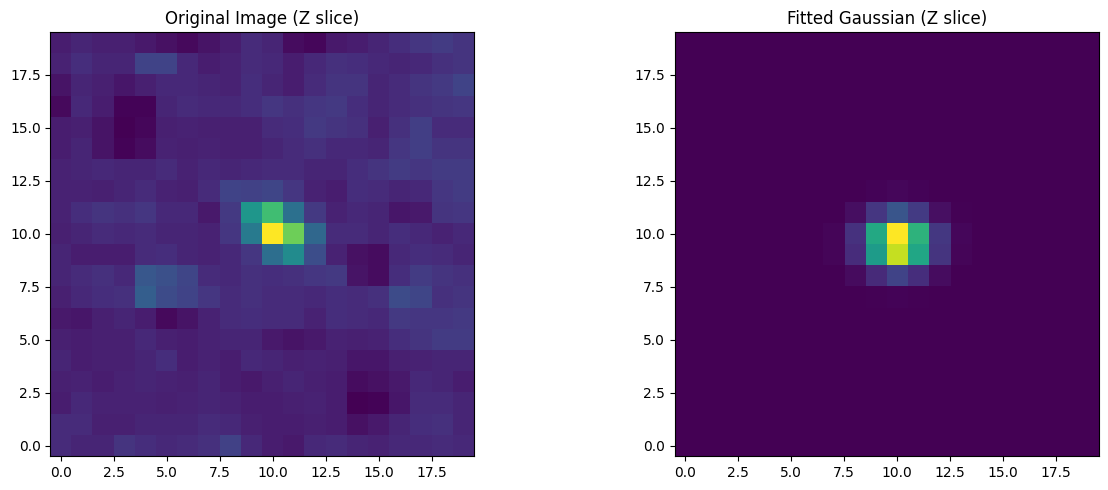

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from random import sample
from copy import deepcopy


def filter_by_gaussian_fit(img, center, radius=3):
    img_vals, coords, params = spg.fit_gaussian(img, center, radius)
    if params is not None:
        corr_coefficient = spg.fitness_quality(img_vals, coords, params)
        if corr_coefficient > 0.7:
            print("Fit accepted:", corr_coefficient)
        else:
            print("Fit rejected:", corr_coefficient)
    return params


if __name__ == "__main__":
    # Parameters
    d = 10

    # Fit a Gaussian to the blob
    while True:
        center = sample(centers, 1)[0]
        img_subpatch = deepcopy(
            img_patch[
                center[0]-d:center[0]+d,
                center[1]-d:center[1]+d,
                center[2]-d:center[2]+d,
            ]
        )
        if all([s == 2 * d for s in img_subpatch.shape]):
            break
    result = filter_by_gaussian_fit(img_subpatch, (d, d, d))

    # Visualization
    fig, axs = plt.subplots(1, 2, figsize=(13, 5))
    slice_z = 10  # Visualize the central Z slice

    axs[0].imshow(img_subpatch[:, :, slice_z], cmap='viridis', origin='lower')
    axs[0].set_title("Original Image (Z slice)")

    if result is not None:
        # Generate the fitted Gaussian for visualization
        x = np.linspace(0, 2 * d, 2 * d)
        y = np.linspace(0, 2 * d, 2 * d)
        z = np.linspace(0, 2 * d, 2 * d)
        x, y, z = np.meshgrid(x, y, z, indexing='ij')
        fitted_blob = spg.gaussian_3d((x, y, z), *result).reshape(x.shape)

        axs[1].imshow(fitted_blob[:, :, slice_z], cmap='viridis', origin='lower')
        axs[1].set_title("Fitted Gaussian (Z slice)")

        plt.tight_layout()
        plt.show()
